# Wykorzystanie rozkładów macierzy do rozwiązywania oznaczonych układów równań

Poznane na wykładzie rozkłady (faktoryzacje) macierzy możemy wykorzystać do rozwiązywania układów równań liniowych. Dzięki wykorzystaniu specjalnych własności macierzy występujących w rozkładzie jesteśmy w stanie w łatwiejszy sposób odwrócić macierz i tym samym zminimalizować błąd.


**Zadanie 1.**

Rozważmy układ równań $Ax=b$, w którym:
* $A$ jest macierzą Hilberta o wymiarach 15x15.
* $A$ jest macierzą wartości losowych z przedziału $[0,100]$ o wymiarach 100x100,  1000x1000 i 1000000x1000000.
* $b$ jest wektorem wartości losowych, odpowiednio, o wymiarach 15x1, 100x1, 1000x1 i 1000000x1.

1. Oblicz współczynnik uwarunkowania macierzy $A$ i oceń jej uwarunkowanie.
2. Rozwiąż układ równań następującymi metodami:
    * z użyciem jawnej odwrotności $A$.
    * korzystając z rozkładu [LU](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lu.html) (uwaga na macierz permutacji!):
        * z wykorzystaniem odwrotności L i U.
        * z użyciem jedynie odwrotności i metody podstawiania wstecznego.
    * korzystając z rozkładu [QR](https://numpy.org/doc/stable/reference/generated/numpy.linalg.qr.html):
        * z wykorzystaniem odwrotności Q i R.
        * z użyciem jedynie odwrotności Q i metody podstawiania wstecznego.
    * za pomocą jednej z metod iteracyjnych z poprzedniego ćwiczenia.
    * za pomocą metody [`solve`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html) z pakietu NumPy.
3. Porównaj otrzymane wyniki. W tym celu oblicz normy z residuuów otrzymanych dla każdego z rozwiązań. Którą z metod cechuje najwyższa dokladność?
4. Przeprowadź porównanie wydajności ww. metod. Zmierz czas wykonania każdej metody. Aby otrzymać bardziej sensowny wynik należy powtórzyć obliczenia w pętli (np. 100 lub 1000 razy) i uśrednić wynik. Do pomiaru czasu wykonania możesz wykorzystać pakiet `time`.
Wskazówka: Do rozwiązania układu z macierzą trójkątną możesz wykorzystać funkcję [`scipy.linalg.solve_triangular`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.solve_triangular.html).

        
        


In [ ]:
import numpy as np
import scipy.linalg as la
import time

N = 100
A = np.random.rand(N, N) * 100
b = np.random.rand(N, 1)

# 1
cond_A = np.linalg.cond(A)
print(f"Współczynnik uwarunkowania macierzy (100x100): {cond_A:.2e}")

# 2. Różne metody rozwiązywania
# Metoda 1
start = time.time()
x_inv = np.linalg.inv(A) @ b
time_inv = time.time() - start

# Metoda 2
start = time.time()
lu, piv = la.lu_factor(A)
x_lu = la.lu_solve((lu, piv), b)
time_lu = time.time() - start

# Metoda 3
start = time.time()
Q, R = np.linalg.qr(A)

y_qr = Q.T @ b
x_qr = la.solve_triangular(R, y_qr)
time_qr = time.time() - start

# Metoda 4: numpy.linalg.solve 
start = time.time()
x_solve = np.linalg.solve(A, b)
time_solve = time.time() - start

# 3. Normy residuów 
print(f"Błąd (residuu) - Jawna odwrotność: {np.linalg.norm(A @ x_inv - b):.2e}")
print(f"Błąd (residuu) - Rozkład LU: {np.linalg.norm(A @ x_lu - b):.2e}")
print(f"Błąd (residuu) - Rozkład QR: {np.linalg.norm(A @ x_qr - b):.2e}")
print(f"Błąd (residuu) - np.linalg.solve: {np.linalg.norm(A @ x_solve - b):.2e}")

Współczynnik uwarunkowania macierzy (100x100): 3.85e+03
Błąd (residuu) - Jawna odwrotność: 1.28e-13
Błąd (residuu) - Rozkład LU: 1.29e-13
Błąd (residuu) - Rozkład QR: 4.28e-14
Błąd (residuu) - np.linalg.solve: 1.29e-13


# Interpolacja

**Zadanie 2.**

Przeprowadź interpolacje poniższych funkcji $f(x)$ za pomocą wielomianów interpolacyjnych Lagrange'a ([`scipy.interpolate.lagrange`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.lagrange.html)). Stwórz wykresy funkcji interpolacyjnych i zaznacz na nich punkty, w ktorych dokonano oceny wartości funkcji.

Pierwsza funkcja:

* $f(0) = 1$,
* $f(0.25) = 1.64872$,
* $f(0.5) = 2.71828$,
* $f(0.75) = 4.48169.$

Oblicz $f(0.43)$.

Druga funkcja:

* $f_2(0.1) = 0.62049958$,
* $f_2(0.2) = -0.28398668$,
* $f_2(0.3) = 0.00660095$,
* $f_2(0.4) = 0.24842440$. 

Oblicz $f_2(0.25)$.

In [2]:
from scipy.interpolate import lagrange

# Pierwsza funkcja
x1 = np.array([0, 0.25, 0.5, 0.75])
y1 = np.array([1, 1.64872, 2.71828, 4.48169])
poly1 = lagrange(x1, y1)
val_043 = poly1(0.43)
print(f"Wartość f1(0.43) = {val_043:.5f}")

# Druga funkcja
x2 = np.array([0.1, 0.2, 0.3, 0.4])
y2 = np.array([0.62049958, -0.28398668, 0.00660095, 0.24842440])
poly2 = lagrange(x2, y2)
val_025 = poly2(0.25)
print(f"Wartość f2(0.25) = {val_025:.5f}")

Wartość f1(0.43) = 2.36060
Wartość f2(0.25) = -0.21034


***Zadanie 3.***

Rozważmy funkcję $f(x)=\frac{1}{25x^2+1}$. 

Przeprowadź interpolacje funkcji $f$ w przedziale $[-2,2]$ wielomianem Lagrange'a oraz funkcjami sklejanymi 3 stopnia w:
- 21 równoodległych węzłach,
- 21 węzłach [Czebyszewa](https://pl.wikipedia.org/wiki/Węzły_Czebyszewa).

**Wskazówka** Interpolację funkcjami sklejanymi możesz przeprowadzić za pomocą funkcji [`interp1d`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.interp1d.html#scipy.interpolate.interp1d).

Umieść wielomian interpolacyjny, oryginalną funkcję $f$ oraz węzly interpolacyjne na wspólnym wykresie (jeden wykres dla metody Lagrange'a oraz jeden dla funkcji sklejanych). Porównaj otrzymane rezultaty. Przeprowadź te same działania dla przedziału $x\in[-5,5]$. Jakie problemy możesz zauważyć na otrzymanych wykresach?

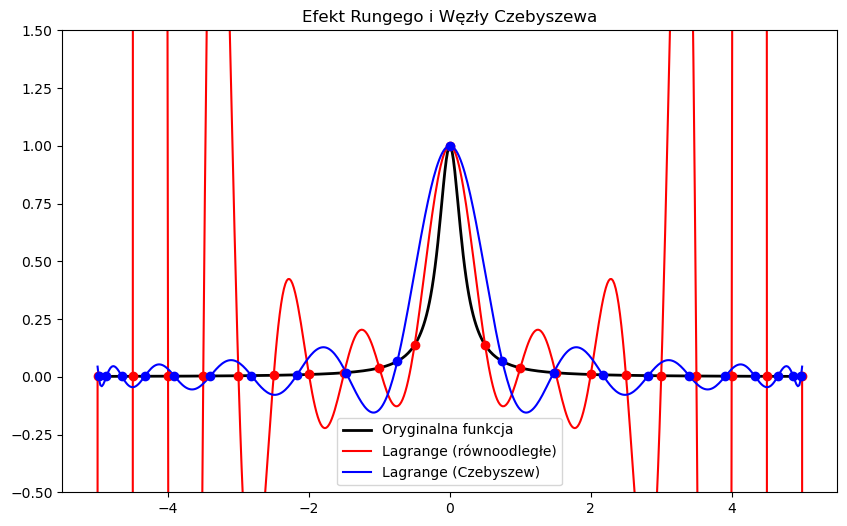

In [8]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
def f_runge(x):
    return 1 / (25 * x**2 + 1)

def chebyshev_nodes(a, b, n):
    k = np.arange(1, n + 1)
    nodes = np.cos((2 * k - 1) / (2 * n) * np.pi)
    return 0.5 * (a + b) + 0.5 * (b - a) * nodes

a, b = -5, 5 
n_nodes = 21

x_dense = np.linspace(a, b, 500)
y_dense = f_runge(x_dense)

# Węzły równoodległe
x_eq = np.linspace(a, b, n_nodes)
y_eq = f_runge(x_eq)
poly_eq = lagrange(x_eq, y_eq)

# Węzły Czebyszewa
x_cheb = chebyshev_nodes(a, b, n_nodes)
y_cheb = f_runge(x_cheb)
poly_cheb = lagrange(x_cheb, y_cheb)

# Funkcje sklejane
spline_eq = interp1d(x_eq, y_eq, kind='cubic')

plt.figure(figsize=(10, 6))
plt.plot(x_dense, y_dense, label='Oryginalna funkcja', color='black', linewidth=2)
plt.plot(x_dense, poly_eq(x_dense), label='Lagrange (równoodległe)', color='red')
plt.plot(x_dense, poly_cheb(x_dense), label='Lagrange (Czebyszew)', color='blue')
plt.scatter(x_eq, y_eq, color='red', zorder=5)
plt.scatter(x_cheb, y_cheb, color='blue', zorder=5)
plt.ylim(-0.5, 1.5) # Ograniczenie osi, bo przy [-5, 5] równoodległe wybuchną do nieskończoności
plt.legend()
plt.title('Efekt Rungego i Węzły Czebyszewa')
plt.show()

***Zadanie 4.***

Kierowca jadący z miasta A do miasta B, zauważywszy na drodze fotoradar, zaczął gwałtownie hamować. Przebieg jego położenia, zarejestrowany przez nawigację, pokazano w poniższej tabeli. Wiedząc, że radar znajduje się w punkcie o współrzędnej 79.6 m, oszacuj kiedy kierowca minął fotoradar (w tym celu skorzystaj z jednej z metod z laboratorium 3) oraz z jaką prędkością wtedy jechał (wykorzystaj relację drogi i prędkości znaną z fizyki). 

|czas \[s\]|położenie \[m\]|
|--|--|
|0.0|0.0|
|1.0|42.7|
|2.0|73.2|
|3.0|92.5|

**Zadanie dla zainteresowanych programowaniem funkcyjnym w Pythonie**

Stwórz funkcję znajdującą wielomian interpolacyjny metodą Lagrange'a. Funkcja powinna przyjmować dwie listy:
* listę argumentów ($x$-ów)
* listę wartości ($y$-ów).  


Po wykonaniu obliczeń funkcja powinna zwracać wielomian w postaci obiektu typu **funkcja** (a nie `numpy.Polynomial`).

**Wskazówka** Wykorzystaj wyrażenia *lambda*. Dla ułatwienia możesz się też posłużyć pakietami `operator` i `functools`.
